# Análisis Exploratorio y Selección de Variables

En este notebook se realiza el análisis exploratorio del dataset maestro construido previamente.

Los objetivos son:

- Comprender la distribución de las variables.
- Analizar la variable objetivo.
- Detectar correlaciones.
- Identificar posibles problemas de multicolinealidad.
- Seleccionar las variables más relevantes para el entrenamiento de modelos de Machine Learning.

## 1. Importación de librerías

Se cargan las librerías necesarias para el análisis estadístico y visualización de datos.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del dataset

Se carga el dataset final generado en la fase de preparación de datos.

In [3]:
dataset = pd.read_csv(
    "../data/processed/dataset_mundial_final.csv"
)

## 3. Inspección inicial

Se verifica la estructura general del dataset.

In [4]:
dataset.head()

,date,home_team,away_team,home_score,away_score,tournament,tournament_weight,neutral,goal_diff,fifa_rank_home,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
0,2000-03-19,Cayman Islands,Cuba,0.0,0.0,FIFA World Cup qualification,6,False,0.0,149.0,...,1.0,-1.0,5.0,8.0,7.0,1.0,-4.0,-8.0,-6.0,-2.0
1,2000-03-19,Dominica,Haiti,1.0,3.0,FIFA World Cup qualification,6,False,-2.0,152.0,...,0.0,2.0,7.0,5.0,12.0,-7.0,-4.0,-3.0,-12.0,9.0
2,2000-03-19,Bermuda,British Virgin Islands,9.0,0.0,FIFA World Cup qualification,6,False,9.0,157.0,...,2.0,-2.0,3.0,4.0,8.0,-4.0,-3.0,-4.0,-6.0,2.0
3,2000-03-25,Bahrain,Jordan,1.0,1.0,Friendly,1,False,0.0,139.0,...,1.0,0.0,8.0,6.0,5.0,1.0,-5.0,-5.0,-4.0,-1.0
4,2000-03-25,Zambia,Botswana,3.0,0.0,COSAFA Cup,3,False,3.0,38.0,...,5.0,1.0,4.0,4.0,8.0,-4.0,2.0,2.0,-3.0,5.0


In [5]:
dataset.shape

(18310, 30)

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 18310 entries, 0 to 18309
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      18310 non-null  str    
 1   home_team                 18310 non-null  str    
 2   away_team                 18310 non-null  str    
 3   home_score                18310 non-null  float64
 4   away_score                18310 non-null  float64
 5   tournament                18310 non-null  str    
 6   tournament_weight         18310 non-null  int64  
 7   neutral                   18310 non-null  bool   
 8   goal_diff                 18310 non-null  float64
 9   fifa_rank_home            18310 non-null  float64
 10  fifa_points_home          18310 non-null  float64
 11  fifa_rank_away            18310 non-null  float64
 12  fifa_points_away          18310 non-null  float64
 13  elo_home                  18310 non-null  float64
 14  elo_away         

In [7]:
dataset.describe()

,home_score,away_score,tournament_weight,goal_diff,fifa_rank_home,fifa_points_home,fifa_rank_away,fifa_points_away,elo_home,elo_away,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
count,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,...,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000,18310.000000
mean,1.554397,1.062643,4.037029,0.491753,75.986565,807.757379,79.481267,790.353762,1546.388367,1523.356745,...,5.178864,2.772966,5.540797,5.396450,7.669252,-2.272802,2.928017,2.555380,-2.490388,5.045767
std,1.515361,1.207853,2.559755,2.095620,52.466815,468.075220,52.416028,459.662314,280.065503,280.509532,...,3.256668,5.820964,3.344356,3.168982,4.233819,6.029459,4.533001,4.838533,4.967477,7.789455
min,0.000000,0.000000,1.000000,-14.000000,1.000000,0.000000,1.000000,0.000000,497.000000,497.000000,...,0.000000,-45.000000,0.000000,0.000000,0.000000,-42.000000,-14.000000,-22.000000,-38.000000,-38.000000
25%,0.000000,0.000000,1.000000,-1.000000,31.000000,418.000000,36.000000,414.000000,1360.000000,1340.000000,...,3.000000,-1.000000,3.000000,3.000000,5.000000,-6.000000,0.000000,-1.000000,-5.000000,0.000000
50%,1.000000,1.000000,4.000000,0.000000,69.000000,714.000000,72.000000,692.000000,1565.000000,1543.000000,...,5.000000,3.000000,5.000000,5.000000,7.000000,-2.000000,3.000000,2.000000,-2.000000,5.000000
75%,2.000000,2.000000,6.000000,2.000000,113.000000,1203.945000,116.000000,1179.000000,1747.000000,1726.000000,...,7.000000,6.000000,8.000000,7.000000,10.000000,2.000000,6.000000,5.000000,1.000000,10.000000
max,17.000000,14.000000,10.000000,17.000000,211.000000,2164.000000,211.000000,2164.000000,2171.000000,2167.000000,...,48.000000,36.000000,15.000000,27.000000,43.000000,25.000000,15.000000,33.000000,38.000000,59.000000


## 4. Verificación de valores faltantes

Se comprueba que el dataset no contiene valores nulos.

In [8]:
dataset.isna().sum()

date                        0
home_team                   0
away_team                   0
home_score                  0
away_score                  0
tournament                  0
tournament_weight           0
neutral                     0
goal_diff                   0
fifa_rank_home              0
fifa_points_home            0
fifa_rank_away              0
fifa_points_away            0
elo_home                    0
elo_away                    0
fifa_rank_diff              0
fifa_points_diff            0
elo_diff                    0
home_last5_points           0
home_last5_goals_for        0
home_last5_goals_against    0
home_last5_goal_balance     0
away_last5_points           0
away_last5_goals_for        0
away_last5_goals_against    0
away_last5_goal_balance     0
form_points_diff            0
form_goals_for_diff         0
form_goals_against_diff     0
form_goal_balance_diff      0
dtype: int64

## 5. Análisis de la variable objetivo

La variable objetivo del problema es la diferencia de goles.

Valores positivos indican victoria del equipo local.

Valores negativos indican victoria del equipo visitante.

El valor cero representa empate.

In [9]:
dataset["goal_diff"].describe()

count    18310.000000
mean         0.491753
std          2.095620
min        -14.000000
25%         -1.000000
50%          0.000000
75%          2.000000
max         17.000000
Name: goal_diff, dtype: float64

In [10]:
dataset["goal_diff"].value_counts().sort_index()

goal_diff
-14.0       1
-13.0       1
-11.0       1
-10.0       4
-9.0        2
-8.0       12
-7.0       22
-6.0       63
-5.0       95
-4.0      247
-3.0      647
-2.0     1385
-1.0     2730
 0.0     4375
 1.0     3871
 2.0     2355
 3.0     1238
 4.0      630
 5.0      318
 6.0      153
 7.0       83
 8.0       35
 9.0       16
 10.0      14
 11.0       2
 12.0       1
 13.0       2
 14.0       4
 15.0       1
 16.0       1
 17.0       1
Name: count, dtype: int64

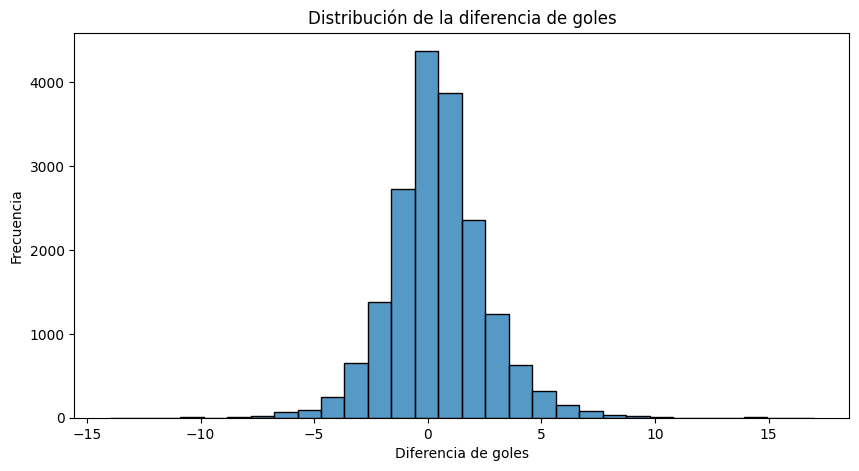

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataset["goal_diff"],
    bins=30
)

plt.title("Distribución de la diferencia de goles")
plt.xlabel("Diferencia de goles")
plt.ylabel("Frecuencia")

plt.savefig(
    "histograma_goal_diff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretación

La distribución de la diferencia de goles se concentra alrededor del valor 0.

Esto indica que la mayoría de los partidos internacionales suelen resolverse por márgenes reducidos, mientras que las goleadas representan una proporción mucho menor de los encuentros.

La distribución presenta una forma aproximadamente simétrica, lo que justifica el uso de técnicas de regresión para modelar esta variable objetivo.

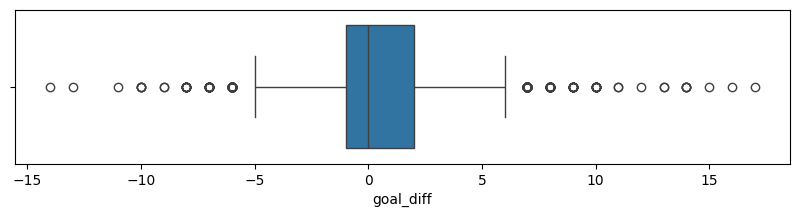

In [12]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=dataset["goal_diff"]
)

plt.show()

### Interpretación

Se observan algunos valores extremos asociados a goleadas poco frecuentes.

Sin embargo, la mayor parte de los partidos se concentra en diferencias de goles cercanas a cero.

Estos resultados son coherentes con el comportamiento habitual del fútbol internacional y no justifican la eliminación de los valores extremos, ya que representan resultados reales observados en competición.

## Conclusiones preliminares

El dataset final contiene 16.704 partidos internacionales disputados entre 2000 y 2025.

No existen valores faltantes y todas las variables necesarias para el modelado están disponibles.

Se ha realizado una primera inspección de la variable objetivo (goal_diff), observándose una distribución centrada en valores próximos al empate, con presencia de algunas goleadas extremas menos frecuentes.

El análisis detallado de correlaciones y selección de variables se realizará en las siguientes fases del proyecto.

# 4. Variables numéricas

In [13]:
numeric_cols = dataset.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['home_score', 'away_score', 'tournament_weight', 'goal_diff',
       'fifa_rank_home', 'fifa_points_home', 'fifa_rank_away',
       'fifa_points_away', 'elo_home', 'elo_away', 'fifa_rank_diff',
       'fifa_points_diff', 'elo_diff', 'home_last5_points',
       'home_last5_goals_for', 'home_last5_goals_against',
       'home_last5_goal_balance', 'away_last5_points', 'away_last5_goals_for',
       'away_last5_goals_against', 'away_last5_goal_balance',
       'form_points_diff', 'form_goals_for_diff', 'form_goals_against_diff',
       'form_goal_balance_diff'],
      dtype='str')

## Correlación entre variables

Se estudian las relaciones lineales entre las variables numéricas para detectar redundancias y posibles problemas de multicolinealidad.

In [14]:
corr = dataset[numeric_cols].corr()

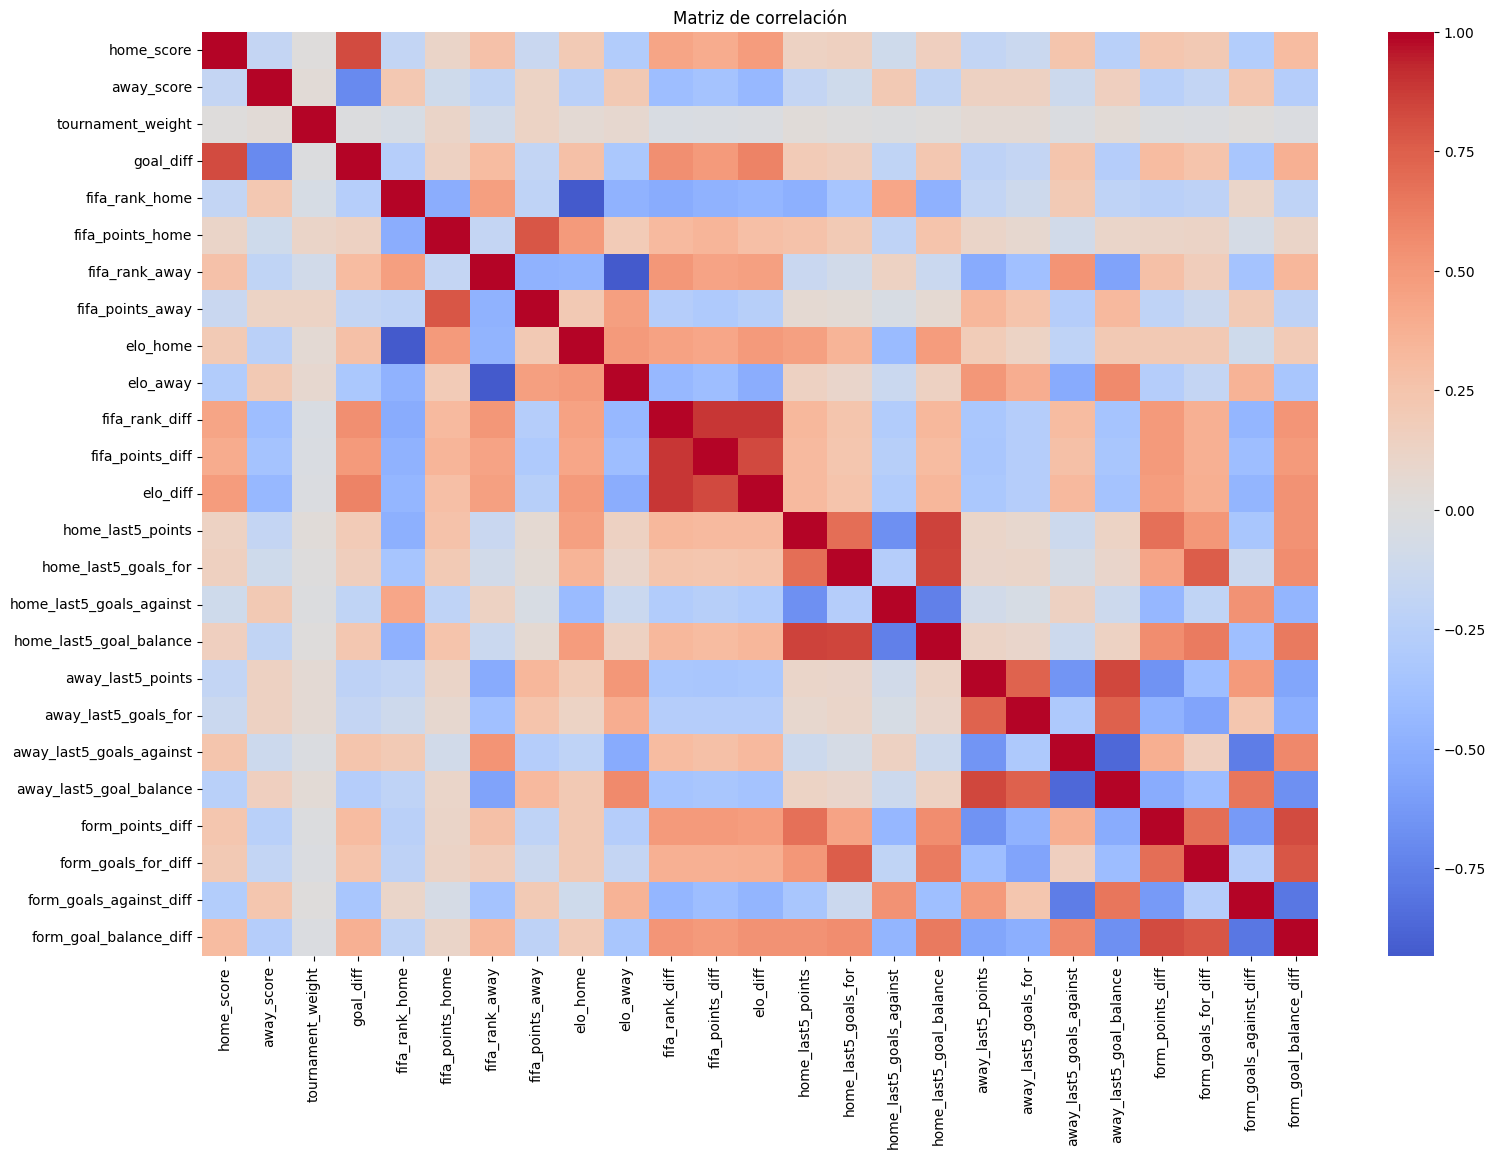

In [15]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

### Interpretación

La matriz de correlación permite identificar relaciones lineales entre las variables del dataset.

Se observa una fuerte relación entre variables derivadas de una misma fuente de información, especialmente entre las métricas FIFA y Elo.

Asimismo, algunas variables relacionadas con el rendimiento reciente presentan correlaciones moderadas con la diferencia de goles, lo que sugiere que pueden aportar capacidad predictiva al modelo.

In [16]:
corr_goal = (
    corr["goal_diff"]
    .sort_values(ascending=False)
)

corr_goal

goal_diff                   1.000000
home_score                  0.823309
elo_diff                    0.604010
fifa_rank_diff              0.548899
fifa_points_diff            0.497507
form_goal_balance_diff      0.375211
form_points_diff            0.310295
fifa_rank_away              0.308379
elo_home                    0.278603
form_goals_for_diff         0.255156
away_last5_goals_against    0.245799
home_last5_goal_balance     0.226679
home_last5_points           0.199047
home_last5_goals_for        0.167550
fifa_points_home            0.146201
tournament_weight          -0.010308
away_last5_goals_for       -0.177512
fifa_points_away           -0.178470
home_last5_goals_against   -0.198805
away_last5_points          -0.215451
fifa_rank_home             -0.259441
away_last5_goal_balance    -0.265894
elo_away                   -0.327574
form_goals_against_diff    -0.339832
away_score                 -0.702080
Name: goal_diff, dtype: float64

In [17]:
dataset["neutral"] = dataset["neutral"].astype(int)

In [18]:
corr = dataset.corr(numeric_only=True)
corr

,home_score,away_score,tournament_weight,neutral,goal_diff,fifa_rank_home,fifa_points_home,fifa_rank_away,fifa_points_away,elo_home,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
home_score,1.000000,-0.173847,0.013941,-0.080189,0.823309,-0.181995,0.116444,0.271786,-0.142020,0.200634,...,-0.107494,0.161427,-0.181808,-0.132462,0.245913,-0.242297,0.237763,0.208608,-0.280066,0.308183
away_score,-0.173847,1.000000,0.035375,0.072524,-0.702080,0.221799,-0.107568,-0.194055,0.131468,-0.231662,...,0.210065,-0.190763,0.145712,0.141798,-0.117940,0.157343,-0.240065,-0.180978,0.238239,-0.264347
tournament_weight,0.013941,0.035375,1.000000,0.050286,-0.010308,-0.052325,0.109513,-0.089046,0.130015,0.048862,...,-0.011959,0.014226,0.052497,0.049786,-0.026659,0.044886,-0.017342,-0.023542,0.014881,-0.024114
neutral,-0.080189,0.072524,0.050286,1.000000,-0.099786,0.009043,0.048100,0.009405,0.040314,-0.008912,...,-0.034964,0.025105,0.035481,0.011582,-0.038478,0.033106,0.006944,-0.000916,0.009873,-0.006865
goal_diff,0.823309,-0.702080,-0.010308,-0.099786,1.000000,-0.259441,0.146201,0.308379,-0.178470,0.278603,...,-0.198805,0.226679,-0.215451,-0.177512,0.245799,-0.265894,0.310295,0.255156,-0.339832,0.375211
fifa_rank_home,-0.181995,0.221799,-0.052325,0.009043,-0.259441,1.000000,-0.504748,0.464981,-0.202360,-0.932675,...,0.430026,-0.481044,-0.182754,-0.113681,0.204297,-0.203204,-0.237764,-0.214824,0.107800,-0.202187
fifa_points_home,0.116444,-0.107568,0.109513,0.048100,0.146201,-0.504748,1.000000,-0.177556,0.787590,0.489060,...,-0.205346,0.254492,0.112764,0.076990,-0.089016,0.102970,0.116570,0.117529,-0.058755,0.110474
fifa_rank_away,0.271786,-0.194055,-0.089046,0.009405,0.308379,0.464981,-0.177556,1.000000,-0.475706,-0.467399,...,0.133161,-0.138496,-0.528007,-0.385331,0.525096,-0.571240,0.279345,0.175381,-0.360243,0.338674
fifa_points_away,-0.142020,0.131468,0.130015,0.040314,-0.178470,-0.202360,0.787590,-0.475706,1.000000,0.213087,...,-0.043578,0.057536,0.338875,0.259467,-0.272827,0.327947,-0.204596,-0.130050,0.203963,-0.210853
elo_home,0.200634,-0.231662,0.048862,-0.008912,0.278603,-0.932675,0.489060,-0.467399,0.213087,1.000000,...,-0.421209,0.482541,0.188019,0.128651,-0.201252,0.208934,0.211700,0.212755,-0.104615,0.198871


# Conclusiones del análisis exploratorio

Tras el análisis estadístico y de correlación se observa que:

- Las variables derivadas de Elo presentan la mayor relación con la diferencia de goles.
- Las variables FIFA también aportan información relevante.
- Las métricas de forma reciente muestran capacidad predictiva adicional.
- Existen relaciones de correlación entre algunas variables, aunque la selección definitiva se realizará durante la fase de entrenamiento.

El dataset queda preparado para la construcción de modelos predictivos.

## Variables disponibles antes del partido

Se eliminan aquellas variables que contienen información del resultado final del encuentro y que, por tanto, no estarían disponibles en el momento de realizar una predicción.

In [19]:
variables_modelo = [
    "tournament_weight",
    "neutral",

    "fifa_rank_home",
    "fifa_points_home",
    "fifa_rank_away",
    "fifa_points_away",

    "elo_home",
    "elo_away",

    "fifa_rank_diff",
    "fifa_points_diff",
    "elo_diff",

    "home_last5_points",
    "home_last5_goals_for",
    "home_last5_goals_against",
    "home_last5_goal_balance",

    "away_last5_points",
    "away_last5_goals_for",
    "away_last5_goals_against",
    "away_last5_goal_balance",

    "form_points_diff",
    "form_goals_for_diff",
    "form_goals_against_diff",
    "form_goal_balance_diff"
]

target = "goal_diff"

In [20]:
dataset.to_csv(
    "dataset_modelado.csv",
    index=False
)

## Distribución del rating Elo

El sistema Elo es una de las variables más importantes del modelo. Analizamos cómo se distribuyen las puntuaciones Elo de las selecciones presentes en el dataset.

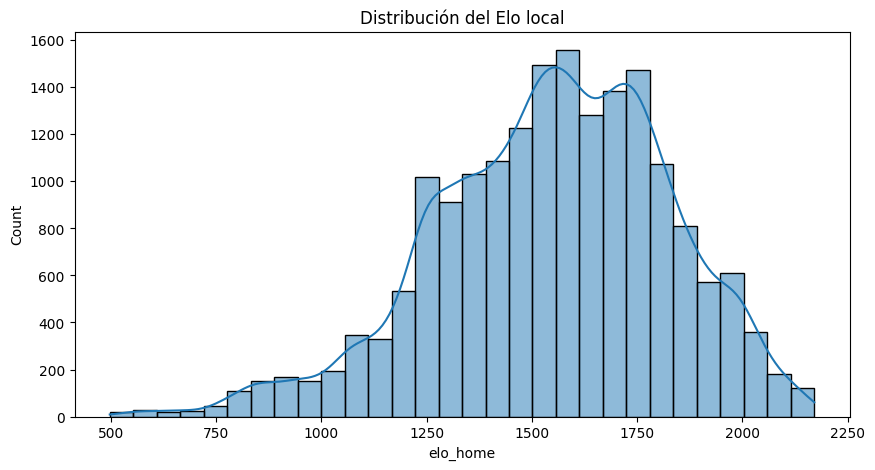

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataset["elo_home"],
    bins=30,
    kde=True
)

plt.title(
    "Distribución del Elo local"
)

plt.show()

### Interpretación

La distribución de puntuaciones Elo presenta una concentración en valores intermedios y una menor presencia de selecciones con puntuaciones extremadamente altas o bajas.

Esto refleja la existencia de un grupo reducido de selecciones de élite y una mayor cantidad de equipos con niveles competitivos similares.

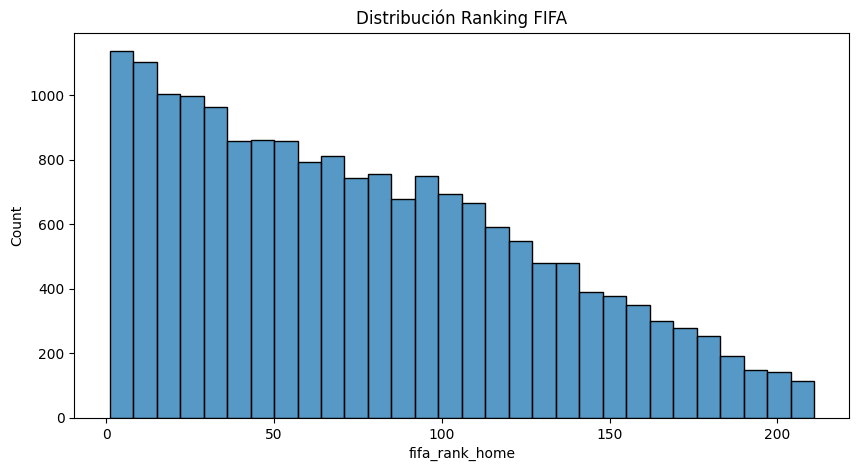

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataset["fifa_rank_home"],
    bins=30
)

plt.title(
    "Distribución Ranking FIFA"
)

plt.show()

### Interpretación

La distribución del ranking FIFA muestra una representación amplia de selecciones pertenecientes a distintos niveles competitivos.

Esto resulta positivo para el entrenamiento del modelo, ya que permite aprender patrones tanto de enfrentamientos equilibrados como de partidos con diferencias significativas de nivel.

## Relación entre Elo y rendimiento deportivo

Se analiza la relación entre la diferencia Elo entre dos selecciones y la diferencia real de goles obtenida en el partido.

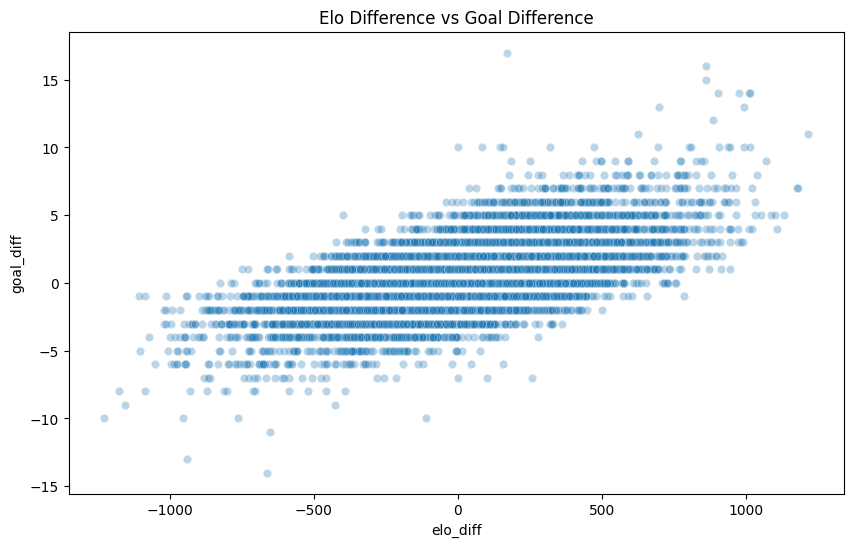

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=dataset,
    x="elo_diff",
    y="goal_diff",
    alpha=0.3
)

plt.title(
    "Elo Difference vs Goal Difference"
)

plt.show()

### Interpretación

Se aprecia una tendencia positiva entre la diferencia Elo y la diferencia de goles observada.

En general, cuando una selección presenta una ventaja importante en Elo sobre su rival, tiende a obtener mejores resultados deportivos.

No obstante, la dispersión de los puntos evidencia la existencia de una elevada incertidumbre inherente al fútbol, lo que justifica la incorporación de un componente aleatorio.

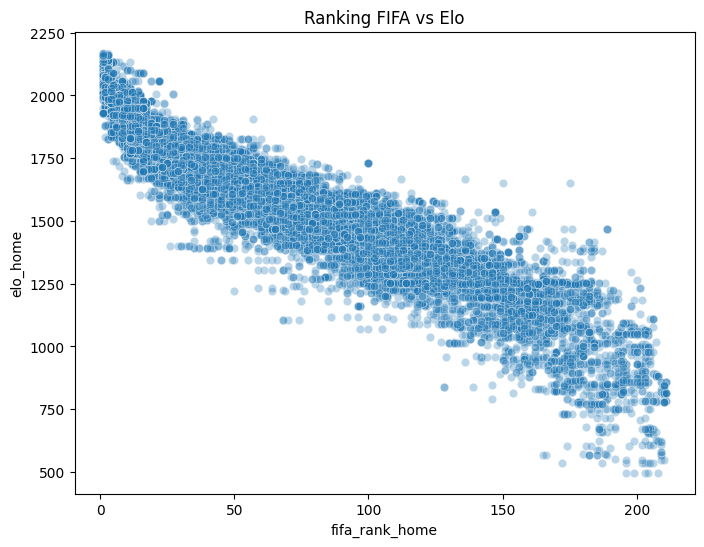

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=dataset,
    x="fifa_rank_home",
    y="elo_home",
    alpha=0.3
)

plt.title(
    "Ranking FIFA vs Elo"
)

plt.show()

### Interpretación

Existe una relación clara entre el ranking FIFA y el sistema Elo.

Las selecciones mejor clasificadas suelen presentar puntuaciones Elo más elevadas.

Sin embargo, la relación no es perfectamente lineal, lo que indica que ambos indicadores aportan información complementaria sobre la fortaleza de una selección.

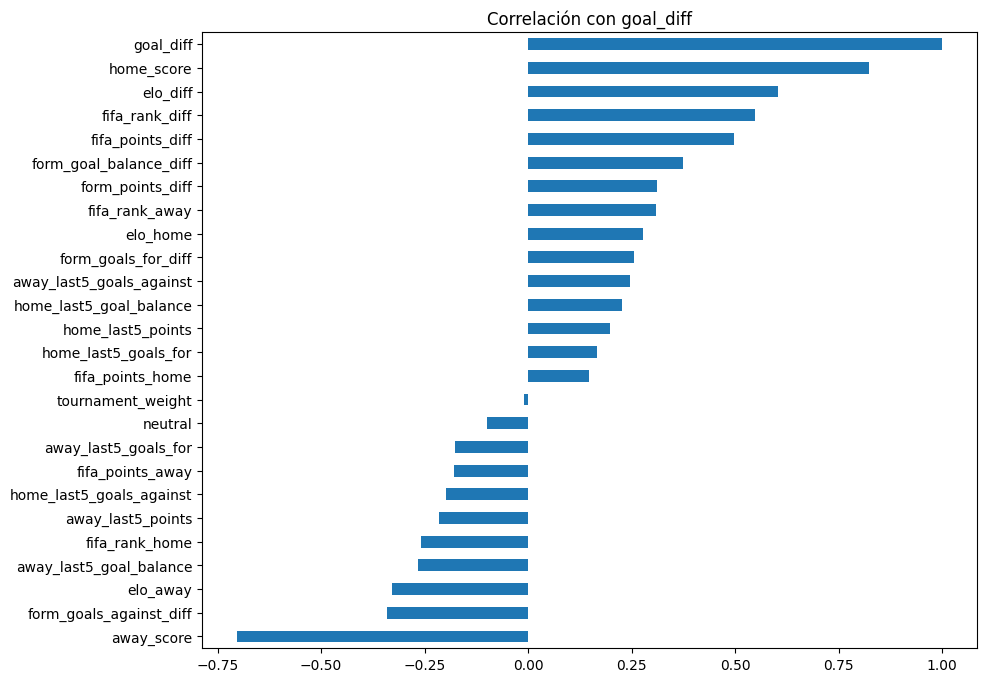

In [25]:
corr_goal = (
    corr["goal_diff"]
    .sort_values()
)

plt.figure(figsize=(10,8))

corr_goal.plot(
    kind="barh"
)

plt.title(
    "Correlación con goal_diff"
)

plt.show()

### Interpretación

Las variables más correlacionadas con la diferencia de goles son aquellas relacionadas con la calidad histórica de las selecciones y su rendimiento reciente.

Destacan especialmente las diferencias de Elo, ranking FIFA y métricas de forma reciente, lo que confirma su relevancia para la construcción del modelo predictivo.

# Conclusión del análisis exploratorio

El análisis exploratorio confirma que las variables relacionadas con la calidad histórica de las selecciones (Elo y ranking FIFA) y su rendimiento reciente presentan capacidad explicativa sobre la diferencia de goles observada.

Asimismo, la distribución de la variable objetivo y las correlaciones detectadas respaldan el uso de técnicas de regresión para modelar el resultado esperado de un partido internacional.